In [1]:
# Import packages
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import time

In [2]:
# ODE function
def ode_func(y, t, params):
    # Unpack parameters
    mu, theta, eta, k, gamma, gamma_1, gamma_2 = params
    # Unpack state variables
    x, z1, z2 = y
    # ODEs
    dz1 = mu - eta*z1*z2 - gamma_1*z1
    dz2 = theta*x - eta*z1*z2 - gamma_2*z2
    dx = k*z1 - gamma*x
    dy = [dx, dz1, dz2]
    return dy

# Simulation function
def simulate_ode(params, y0, t):
    ode_sol = odeint(ode_func, y0, t, args=(params,))
    return ode_sol

# Equilibrium function
def equilibrium_func(y, params):
    return ode_func(y, 0, params)

In [3]:
# Simulate the ODE model
y0 = [0.01, 0.01, 0.01]
mu = 100; theta = 1; eta = 10; k = 10; gamma = 1; gamma_1 = 0; gamma_2 = 0
params = [mu, theta, eta, k, gamma, gamma_1, gamma_2]
t = np.linspace(0, 20, 1000)
start_time = time.time()
y = simulate_ode(params, y0, t)
end_time = time.time()
elapsed_time1 = end_time - start_time
print('Elapsed time for ODE simulation: %.2f seconds' % elapsed_time1)

Elapsed time for ODE simulation: 0.03 seconds


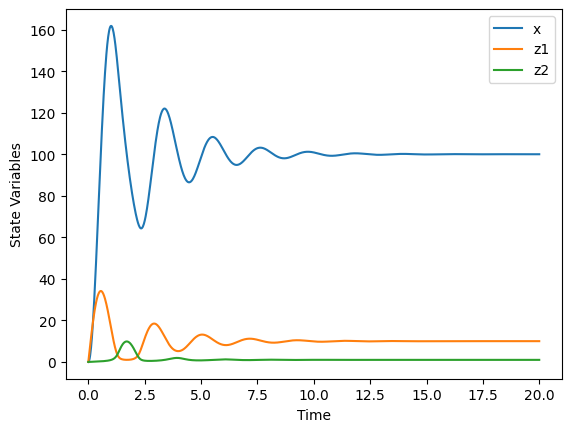

In [4]:
# Plot the results
plt.plot(t, y)
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.legend(['x', 'z1', 'z2'])
plt.show()